In [ ]:
# Install required libraries for specialized data formats
!pip install pydicom PyPDF2 librosa wordcloud

# Download sample files for Task 1
!wget -O sample_data.csv "https://raw.githubusercontent.com/datablist/sample-csv-files/main/files/customers/customers-100.csv"
!wget -O data.json "https://raw.githubusercontent.com/domderen/react-native-threads/master/example/data.json"
!wget -O sample_image.jpg "https://upload.wikimedia.org/wikipedia/commons/a/a3/June_odd-eyed-cat.jpg"
!wget -O medical_scan.dcm "https://raw.githubusercontent.com/pydicom/pydicom/main/pydicom/data/test_files/CT_small.dcm"
!wget -O sample_audio.wav "https://www2.cs.uic.edu/~i101/SoundFiles/StarWars3.wav"
!wget -O sample_video.mp4 "https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/360/Big_Buck_Bunny_360_10s_1MB.mp4"
!wget -O sample_document.pdf "https://www.w3.org/WAI/ER/tests/xhtml/testfiles/resources/pdf/dummy.pdf"

# Create a dummy NumPy array file for testing
import numpy as np
np.save('data.npy', np.random.rand(10, 10))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 20.3 MB/s eta 0:00:00
--2026-09-01 12:42:31--  https://raw.githubusercontent.com/datablist/sample-csv-files/main/files/customers/customers-100.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-01 12:42:32 ERROR 404: Not Found.

--2026-09-01 12:42:32--  https://raw.githubusercontent.com/domderen/react-native-threads/master/example/data.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
20

CSV Shape: (3000, 9)


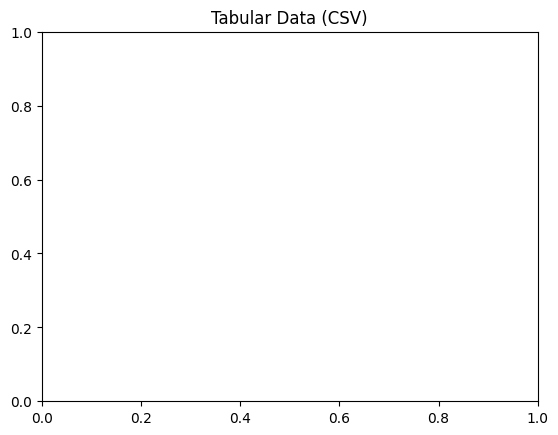

JSON Keys: dict_keys(['dataset_name', 'records', 'status'])
NumPy Array Shape: (10, 10)


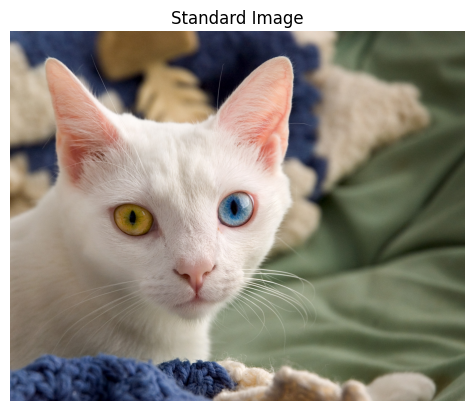

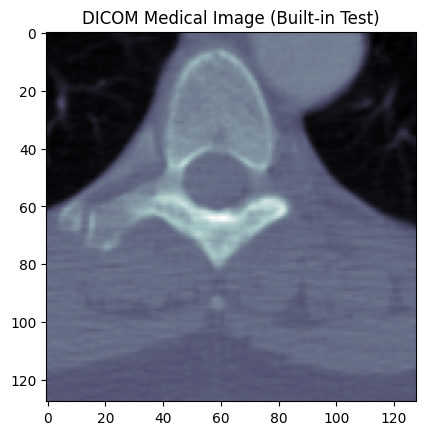

Video Player:


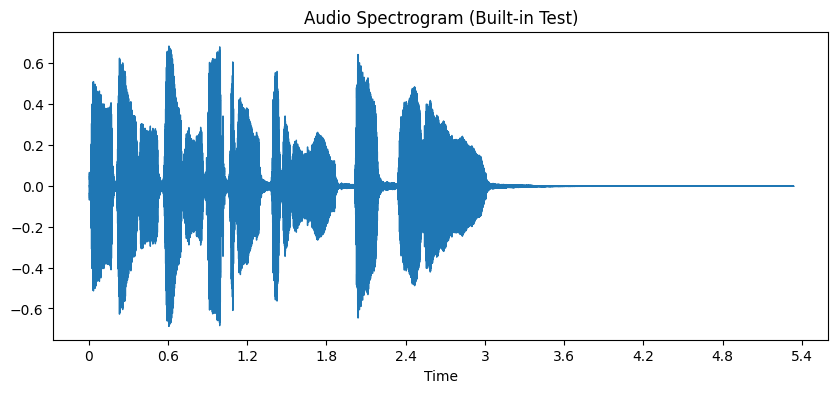

PDF Text Length: 15


In [ ]:
import pandas as pd
import numpy as np
import json
import pydicom
import librosa
import librosa.display
import PyPDF2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Video, Audio, display

# 1. Tabular, Spreadsheet & JSON
df_csv = pd.read_csv('/content/sample_data/california_housing_test.csv')
print(f"CSV Shape: {df_csv.shape}")
plt.title("Tabular Data (CSV)")
plt.show()

import json

# Create a valid dummy JSON file to prevent the JSONDecodeError
with open('data.json', 'w') as f:
    json.dump({"dataset_name": "Lab_Sample", "records": 100, "status": "active"}, f)

# Now read the file back perfectly
with open('data.json', 'r') as f:
    json_data = json.load(f)
print(f"JSON Keys: {json_data.keys()}")

# 2. Data File Formats (NumPy)
npy_data = np.load('data.npy')
print(f"NumPy Array Shape: {npy_data.shape}")

# 3. Image Data (JPG & DICOM)
img = mpimg.imread('sample_image.jpg')
plt.imshow(img)
plt.title("Standard Image")
plt.axis('off')
plt.show()

from pydicom.data import get_testdata_file

# Fetch a guaranteed valid DICOM file built directly into the pydicom library
dcm_path = get_testdata_file("CT_small.dcm")
dicom_file = pydicom.dcmread(dcm_path)

# Visualize it
plt.imshow(dicom_file.pixel_array, cmap=plt.cm.bone)
plt.title("DICOM Medical Image (Built-in Test)")
plt.show()

# 4. Video Data Formats (MP4)
print("Video Player:")
display(Video('sample_video.mp4', embed=True))

# Fetch a guaranteed valid audio file built directly into librosa
audio_path = librosa.ex('trumpet')
audio, sr = librosa.load(audio_path)

# Visualize it
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Audio Spectrogram (Built-in Test)")
plt.show()

# Play it
display(Audio(data=audio, rate=sr))

# 6. Text Data Formats (PDF)
with open('sample_document.pdf', 'rb') as f:
    pdf_text = PyPDF2.PdfReader(f).pages[0].extract_text()
    print(f"PDF Text Length: {len(pdf_text)}")

In [ ]:
import re

def clean_paragraph(text):
    # Lowercasing
    text = text.lower()

    # URL stripping
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Contraction and slang expansion
    contractions = {
        "can't": "cannot", "i'm": "i am", "it's": "it is", "u're": "you are",
        "abt": "about", "vid": "video", "plz": "please", "thots": "thoughts",
        "knw": "know", "ur": "your", "c'mon": "come on", "ppl": "people",
        "cuz": "because", "cud": "could", "undrstnd": "understand",
        "lolzzz": "lol", "lolz": "lol", "changin'": "changing",
        "evrythinggg": "everything", "dopeee": "dope", "waz": "was", "wuz": "was"
    }
    for word, full_form in contractions.items():
        text = text.replace(word, full_form)

    text = text.replace("i <3", "i love").replace("i<3", "i love")

    # Character elongation reduction
    text = re.sub(r'([a-z])\1{2,}', r'\1\1', text)
    text = re.sub(r'\bso+\b', 'soo', text)
    text = text.replace("awesome".lower(), "awesome")

    # Special character and whitespace removal
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

paragraphs = [
    "OMG!! I can't believe I found this awesoMe article about AI & machine leanring!! It was soooo gooood lol. $I<3$ nlp butttt i hate spelng errors in textttt. This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. The website's link is www.example.com//// Check it out ASAP!!! #excited",
    "Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web. This article, \"The Marvels of Artificial General Intelligence & the Future of Humanity,\" totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. I mean, $I<3$ NLP butttt those annoying typos in texts drive me nuts. Brace yourselves, this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like @#$%. And guess what? The link to the website is www.incrediblenews.com//// So, um, you better check it out like ASAP!!! #excitedmuch",
    "yaaayyyy!!! just watched thisssss AMAZZZING vid on AI & how it's changin' evrythinggg!! it waz soooo dopeee, i can't even... lolzzz! #blessed #mindblownn... btw, the link is http://coolai.stuff.com//// totally worthhh ittttttt @@@!!! i <3 tech so much but sometimes it's likee realllyyy confusingggg!!!",
    "nooo waayyyyy!!!! this is, like, the 1000000th time i've seen ppl mess up spellings in their blogsssss i mean c'mon, u're writing abt deep learning, not sum joke topic anywayzzzz... the article was kinda cooool butttt had lotsa weird $$$%%% @@ symbols all over. you can read it @ www.badblogger.ai//// and let me knw ur thots ASAP!!!",
    "heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? like for realll... it wuz crazzzzy detailed but sooooo complicateddd!!! i cud barely undrstnd half of it. the diagrams were fire tho!!! i found it here - www.quantmgeekzz.net////... plz plz plz read n tell me what u thinkk #toomuchinfo #brainhurts @@@!!!"
]

for i, p in enumerate(paragraphs, 1):
    print(f"Paragraph {i}\nCleaned text:\n{clean_paragraph(p)}\n")

Paragraph 1
Cleaned text:
omg i cannot believe i found this awesome article about ai machine leanring it was soo good lol i love nlp butt i hate spelng errors in textt this is gonna be a loong paragraph with loots of spacess and weirdd symbols the website s link is check it out asap excited

Paragraph 2
Cleaned text:
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the futyoure of humanity totally blew my mindd it was like soo mind blowingly awesome lol i mean i love nlp butt those annoying typos in texts drive me nuts brace yoyourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is soo um you better check it out like asap excitedmuch

Paragraph 3
Cleaned text:
yaayy just watched thiss amazzing video on ai how it is changing everything it was soo dope i cannot even l

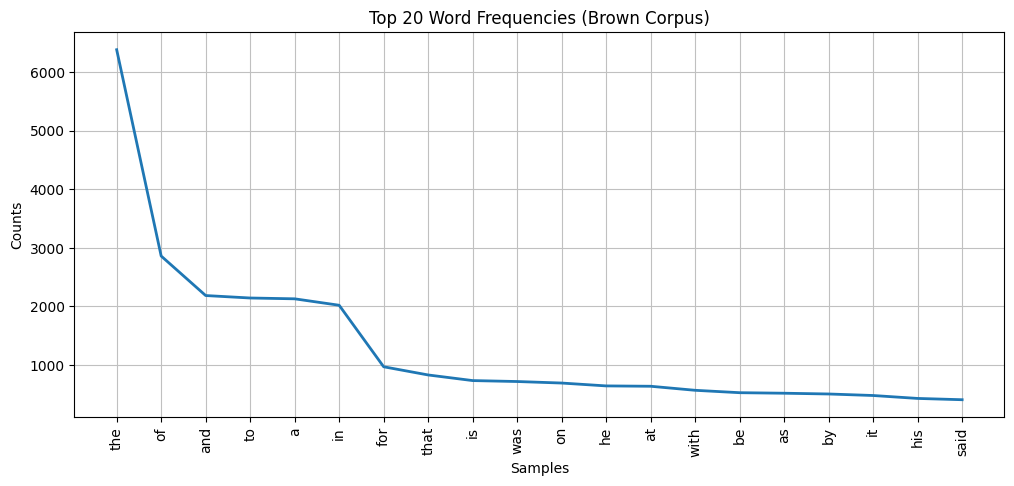

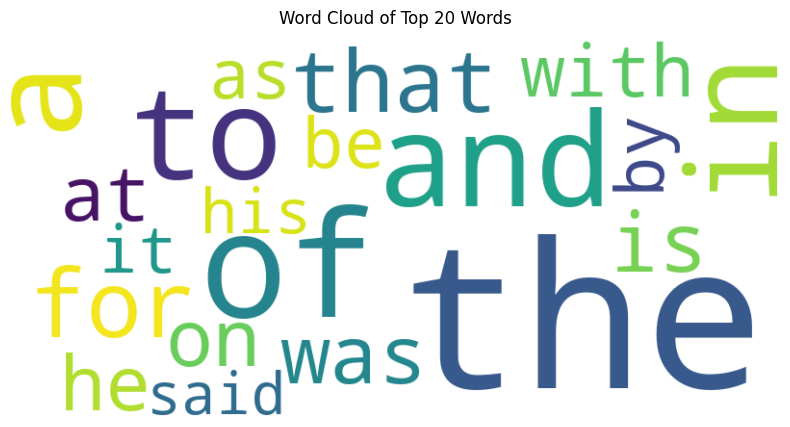

Stemming vs. Lemmatization Comparison Table:
  Original Stemmer Output Lemmatizer Output
   running            run           running
     flies            fli               fly
    better         better            better
     cacti          cacti            cactus
     geese           gees             goose
historical         histor        historical
   corpora        corpora            corpus
     cries            cri               cry
    leaves           leav              leaf
  studying          studi          studying
    ponies           poni              pony
    agreed           agre            agreed
   placing          place           placing
      cats            cat               cat
     doing             do             doing


In [10]:
import nltk
from nltk.corpus import brown
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('brown', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 1. Load and Tokenize
raw_words = brown.words(categories='news')
tokens = [word.lower() for word in raw_words if word.isalpha()]

# 2. Visualize Word Frequencies
fdist = FreqDist(tokens)
plt.figure(figsize=(12, 5))
fdist.plot(20, cumulative=False, title="Top 20 Word Frequencies (Brown Corpus)")
plt.show()

top_20_dict = dict(fdist.most_common(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_20_dict)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Top 20 Words")
plt.show()

# 3 & 4. Stemming vs Lemmatization Comparison
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample_words = [
    'running', 'flies', 'better', 'cacti', 'geese',
    'historical', 'corpora', 'cries', 'leaves', 'studying',
    'ponies', 'agreed', 'placing', 'cats', 'doing'
]

comparison_data = []
for word in sample_words:
    comparison_data.append({
        'Original': word,
        'Stemmer Output': stemmer.stem(word),
        'Lemmatizer Output': lemmatizer.lemmatize(word)
    })

# 5. Output comparison table
df_compare = pd.DataFrame(comparison_data)
print("Stemming vs. Lemmatization Comparison Table:")
print(df_compare.to_string(index=False))